In [10]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.impute import SimpleImputer, KNNImputer
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
# Cargar el conjunto de datos
diabetes = load_diabetes(as_frame=True)
data = diabetes.data
data['target'] = diabetes.target

In [16]:
data.sample(10)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
346,0.005383,0.050680,0.017506,0.032201,0.127771,0.127390,-0.021311,0.071210,0.062578,0.015491,139.0
385,0.023546,0.050680,-0.019140,0.049415,-0.063487,-0.061125,0.004460,-0.039493,-0.025953,-0.013504,219.0
300,0.016281,-0.044642,0.073552,NaN,-0.004321,-0.013527,-0.013948,-0.001116,0.042897,0.044485,275.0
249,-0.012780,-0.044642,0.060618,0.052858,0.047965,0.029375,-0.017629,0.034309,0.070207,0.007207,215.0
42,-0.060003,0.050680,-0.010517,-0.014863,-0.049727,-0.023547,-0.058127,0.015858,-0.009919,-0.034215,61.0
311,0.096197,-0.044642,NaN,-0.057313,0.045213,0.060690,-0.021311,0.036154,0.012551,0.023775,180.0
200,0.056239,-0.044642,-0.057941,-0.007977,0.052093,0.049103,0.056003,-0.021412,-0.028323,0.044485,158.0
271,0.038076,0.050680,0.008883,0.042529,-0.042848,-0.021042,-0.039719,-0.002592,-0.018114,0.007207,127.0
76,-0.030942,0.050680,NaN,0.070072,-0.126781,-0.106845,-0.054446,-0.047981,-0.030748,0.015491,170.0


In [13]:
# Simular valores faltantes
np.random.seed(42)
data.loc[data.sample(frac=0.1).index, 'bmi'] = np.nan
data.loc[data.sample(frac=0.1).index, 'bp'] = np.nan

In [15]:
# Contar valores faltantes por columna
missing_values = data.isnull().sum()
print("Valores faltantes por columna:")
print(missing_values[missing_values > 0])

Valores faltantes por columna:
bmi    44
bp     44
dtype: int64


In [7]:
# Inicializar el imputador simple con la media
imputer_mean = SimpleImputer(strategy='mean')

# Aplicar la imputación a la columna 'bmi' (requiere un arreglo 2D, por eso usamos doble corchete)
data['bmi_imputed_mean'] = imputer_mean.fit_transform(data[['bmi']])

# Verificar que ya no queden nulos en esta nueva columna
print("Valores nulos en 'bmi_imputed_mean':", data['bmi_imputed_mean'].isnull().sum())

Valores nulos en 'bmi_imputed_mean': 0


In [8]:
# Crear una copia del DataFrame para comparar la imputación KNN
data_knn = data.copy()

# Inicializar el KNNImputer (por defecto usa n_neighbors=5)
knn_imputer = KNNImputer(n_neighbors=5)

# Aplicar la imputación a las columnas 'bmi' y 'bp'
data_knn[['bmi', 'bp']] = knn_imputer.fit_transform(data_knn[['bmi', 'bp']])

# Comparación estadística básica entre la imputación simple y KNN para la columna 'bmi'
print("--- Estadísticas Imputación Simple (Media) ---")
print(data['bmi_imputed_mean'].describe()[['mean', 'std']])

print("\n--- Estadísticas KNN Imputer ---")
print(data_knn['bmi'].describe()[['mean', 'std']])

--- Estadísticas Imputación Simple (Media) ---
mean   -0.000205
std     0.044583
Name: bmi_imputed_mean, dtype: float64

--- Estadísticas KNN Imputer ---
mean    0.000213
std     0.045416
Name: bmi, dtype: float64


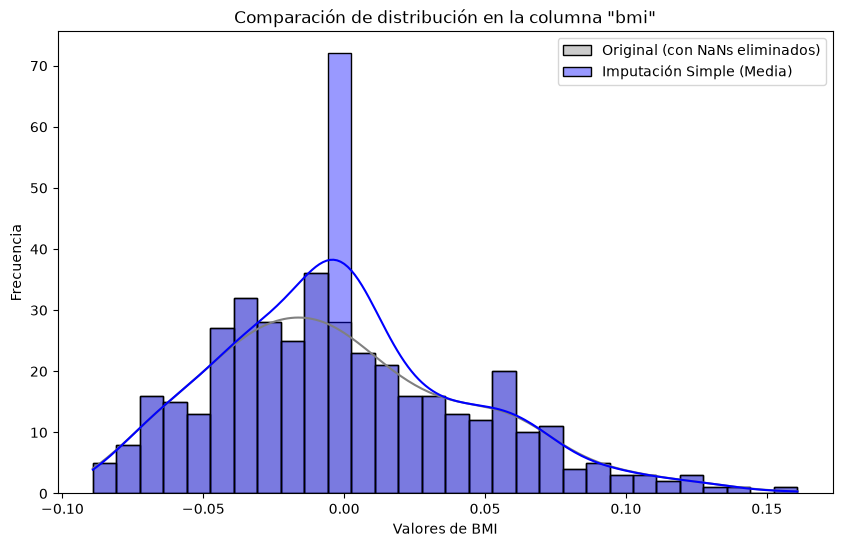

In [9]:
plt.figure(figsize=(10, 6))

# Histograma de los datos originales (sin nulos para evitar errores en el gráfico)
sns.histplot(data['bmi'].dropna(), color='gray', label='Original (con NaNs eliminados)', alpha=0.4, kde=True, bins=30)

# Histograma después de la imputación por media
sns.histplot(data['bmi_imputed_mean'], color='blue', label='Imputación Simple (Media)', alpha=0.4, kde=True, bins=30)

plt.title('Comparación de distribución en la columna "bmi"')
plt.xlabel('Valores de BMI')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()